In [1]:
# Import packages
import pandas as pd
import numpy as np

import ossify as osy
from standard_transform.datasets import v1dd_ds

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
import sys
from os.path import join as pjoin
from typing import Optional, Union
utils_path = "/root/capsule/code/utils"
sys.path.insert(0, utils_path)

import itertools

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import tqdm
from connects_common_connectivity.io import DatasetReader, read_synapse_table
from matplotlib import pyplot as plt
from scipy import spatial, stats
from scipy.sparse import csr_array

from paths import resolve_data_root, resolve_dataset_dir

mat_version = 1196
data_root = resolve_data_root(f"v1dd_{mat_version}_ccm")

# The EM side: cells, cell types and synapses, in Common Connectivity format
ccm_dir = resolve_dataset_dir(f"v1dd_{mat_version}_ccm", root=data_root)

project_id = "v1dd"
synapse_dataset_id = f"v1dd_{mat_version}_em"
synapse_feature_matrix_id = f"v1dd_{mat_version}_synapse_features"
axon_dataset_id = f"v1dd_{mat_version}_proofread_axons"
dendrite_dataset_id = f"v1dd_{mat_version}_proofread_dendrites"

# The two-photon side: its own dataset on CodeOcean, but it sits next to the older feather
# tables if you downloaded those together. Accept either.
functional_dir = resolve_dataset_dir(
    f"v1dd_{mat_version}_coreg_functional_correlation",
    f"v1dd_{mat_version}",
    root=data_root,
)

print(f"ccm_dir        {ccm_dir}")
print(f"functional_dir {functional_dir}")

ccm_dir        /root/capsule/data/v1dd_1196_ccm
functional_dir /root/capsule/data/v1dd_1196_coreg_functional_correlation


In [3]:
import os
from caveclient import CAVEclient

client = CAVEclient("v1dd_public", server_address="https://global.em.brain.allentech.org", auth_token=os.environ["API_SECRET"])


In [4]:
# thalamic_proofreading
# thalamic_table = client.info.get_datastack_info()['thalamic_proofreading']
df_thalamic=client.materialize.query_table('thalamic_proofreading')

In [5]:
# Initialize the Common Connectivity dataset reader
reader = DatasetReader(ccm_dir)
reader.display_dataset_names()  # see available cohorts

id,name,project_id,modality
str,str,str,str
"""v1dd_1196_em""","""V1DD release 1196 — EM somas""","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_axons""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""
"""v1dd_1196_proofread_dendrites""","""V1DD release 1196 — proofread …","""v1dd""","""ELECTRON_MICROSCOPY"""


In [6]:
# Load the features and cell type table of cells with axon and dendrite proofreading
proofread_axons = reader.read_dataset(axon_dataset_id)
proofread_dendrites = reader.read_dataset(dendrite_dataset_id)

# Extract the root IDs of the proofread dendrites and axons
dendrite_proof_root_ids = proofread_dendrites["dataitem_id"].cast(pl.UInt64).to_numpy()
axon_proof_root_ids = proofread_axons["dataitem_id"].cast(pl.UInt64).to_numpy()

print(
    f"There are {len(dendrite_proof_root_ids)} cells with acceptable dendrites, and {len(axon_proof_root_ids)} cells with axon proofreading"
)
proofread_axons.head(3)

There are 63986 cells with acceptable dendrites, and 1164 cells with axon proofreading


dataitem_id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,soma_voxel_x,soma_voxel_y,soma_voxel_z,soma_transformed_x,soma_transformed_y,soma_transformed_z,soma_volume,v1dd_cell_types_level_0,v1dd_cell_types_level_1,v1dd_cell_types_level_2
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f32,f32,str,str,str
"""864691132534275418""",224.539952,228.434194,1.278639,19.476042,0.085259,0.456255,492.136677,612.704786,0.957844,2.03256,0.040803,739373.0,633371.0,323640.0,-148.078156,332.191132,39.439651,224.683212,"""neuron""","""E""","""L4-IT"""
"""864691132534315610""",236.506655,246.509254,1.332867,27.856331,0.113003,0.422036,560.394755,691.239539,1.293702,2.102883,0.088247,823103.0,635932.0,272970.0,-62.355999,320.556305,-10.523945,236.639908,"""neuron""","""E""","""L4-IT"""
"""864691132535664474""",300.20032,264.670537,1.220714,3.614023,0.013655,0.397125,755.934198,923.133835,0.524689,2.300336,0.080162,972173.0,1.006782e6,429480.0,-41.442623,739.148865,7.655986,300.366089,"""neuron""","""E""","""L6-CT"""


In [7]:
thal = client.materialize.query_table("thalamic_proofreading")

thal_ids = (
    thal["pt_root_id"]
    .dropna()
    .unique()
)

thal_ids = [int(x) for x in thal_ids]

print(thal_ids)

[864691132629122108, 864691132572564252, 864691132804540262, 864691132970239597, 864691132843175686, 864691132808826882, 864691132713344581, 864691132685656693, 864691132637633777, 864691132754822188, 864691132729685430, 864691132711724289, 864691132647432268, 864691132804600422, 864691132671726504, 864691132596563511, 864691132796040943, 864691132932298216, 864691132620299719, 864691132619049793, 864691132684290016, 864691132628102040, 864691132664342596, 864691132681842259, 864691132730578923, 864691132657126359, 864691132780869743, 864691132680329565, 864691132748932739, 864691132739826873, 864691132645737598, 864691132599901759, 864691132661526697, 864691133122566501, 864691132667511342, 864691132689345418, 864691132737641387, 864691132810070817, 864691132593374461, 864691132647486796, 864691132599924031, 864691132664372548, 864691132952625994, 864691132680088350, 864691132728470279, 864691133001102261, 864691132960259431, 864691132831254393, 864691132832000260, 864691133050913636,

In [8]:
# # thal_syn_1 = client.materialize.synapse_query(
# #     pre_ids=thal_ids[:50],
# #     desired_resolution=[1, 1, 1]
# # )

# # thal_syn_2 = client.materialize.synapse_query(
# #     pre_ids=thal_ids[50:],
# #     desired_resolution=[1, 1, 1]
# # )

# # thal_syn = pd.concat([thal_syn_1, thal_syn_2], ignore_index=True)

# thal_syn.to_csv('thal_syn.csv', index=False)

In [9]:
thal_syn = pd.read_csv('thal_syn.csv')

In [10]:
thal_syn.head()

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position
0,282681478,2021-11-19 01:35:28.272045+00:00,NaN,True,2902.0,88397162936966358,864691132647486796,88397162936965005,864691132832053252,[665158 653081 511605],[665332 652761 511380],[665051 653062 511560]
1,324977225,2021-11-18 22:16:58.141699+00:00,NaN,True,739.0,89662287497449724,864691132804540262,89591918753323750,864691132612319611,[709739 598771 182340],[709341 598781 182655],[709555 598810 182430]
2,404535272,2021-11-18 22:03:58.345906+00:00,NaN,True,750.0,93321462999446267,864691132647486796,93321462999447466,864691131718083940,[840058 599654 438525],[839622 599624 438525],[839816 599692 438435]
3,417826507,2021-11-19 02:10:08.767039+00:00,NaN,True,1808.0,93532774786769330,864691132843175686,93532774786771710,864691132612319611,[846732 606385 243180],[847130 606638 243405],[846926 606531 243270]
4,295785734,2021-11-18 22:51:18.353664+00:00,NaN,True,2390.0,88465400438245810,864691132629122108,88535769182411361,864691132022324186,[669610 575520 205425],[670105 575520 205740],[669911 575491 205650]


In [11]:
print("thal axons:", thal_syn["pre_pt_root_id"].nunique())
print("post root IDs:", thal_syn["post_pt_root_id"].nunique())
print("synapses:", len(thal_syn))

thal axons: 97
post root IDs: 321532
synapses: 463661


In [12]:
thal_conn = (
    thal_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .agg(
        n_synapses=("id", "count"),
        total_synapse_size=("size", "sum"),
        mean_synapse_size=("size", "mean"),
    )
    .reset_index()
)

thal_conn.head()


,pre_pt_root_id,post_pt_root_id,n_synapses,total_synapse_size,mean_synapse_size
0,864691132537321562,864691128466949053,1,1360.0,1360.0
1,864691132537321562,864691128474129087,1,997.0,997.0
2,864691132537321562,864691128484359153,1,350.0,350.0
3,864691132537321562,864691128485206136,1,714.0,714.0
4,864691132537321562,864691128485640407,1,885.0,885.0


In [13]:
thal_input_per_cell = (
    thal_syn
    .groupby("post_pt_root_id")
    .agg(
        n_synapses=("id", "count"),
        n_thalamic_axons=("pre_pt_root_id", "nunique"),
        total_synapse_size=("size", "sum"),
        mean_synapse_size=("size", "mean"),
    )
    .reset_index()
)

thal_input_per_cell.head()

,post_pt_root_id,n_synapses,n_thalamic_axons,total_synapse_size,mean_synapse_size
0,0,6,5,9991.0,1665.166667
1,864691128456072427,1,1,339.0,339.000000
2,864691128456090329,1,1,1987.0,1987.000000
3,864691128456790098,1,1,431.0,431.000000
4,864691128457382381,1,1,579.0,579.000000


In [14]:
conn_count = thal_conn.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

conn_count.shape

(97, 321532)

In [15]:
conn_count

post_pt_root_id,0,864691128456072427,864691128456090329,864691128456790098,864691128457382381,864691128457503409,864691128457504177,864691128457574221,864691128457842865,864691128457973116,...,864691133314147664,864691133314166096,864691133314168144,864691133314185552,864691133314195280,864691133314201424,864691133314206544,864691133314222928,864691133314231632,864691133314233424
pre_pt_root_id,,,,,,,,,,,,,,,,,,,,,
864691132537321562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132549572162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132572564252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
864691132582739474,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
864691132582742802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864691132970239597,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
864691133001102261,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
864691133050913636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [16]:
neurons = client.materialize.query_table(
    "neurons_soma_model", #A subset of nucleus detections predicted be neurons from a model trained on soma and nucleus features.
)

neuron_ids = set(
    neurons["pt_root_id"]
    .dropna()
    .astype("uint64")
)

thal_syn_neurons = thal_syn[
    thal_syn["post_pt_root_id"].isin(neuron_ids)
].copy()

print(
    "all post roots:",
    thal_syn["post_pt_root_id"].nunique()
)

print(
    "postsynaptic neurons:",
    thal_syn_neurons["post_pt_root_id"].nunique()
)

all post roots: 321532
postsynaptic neurons: 27436


In [17]:
thal_conn_neurons = (
    thal_syn_neurons
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .agg(
        n_synapses=("id", "count"),
        total_synapse_size=("size", "sum")
    )
    .reset_index()
)

conn_count = thal_conn_neurons.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

print(conn_count.shape)

(97, 27436)


In [18]:
conn_size = thal_conn_neurons.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="total_synapse_size"
).fillna(0)

print(conn_size.shape)

(97, 27436)


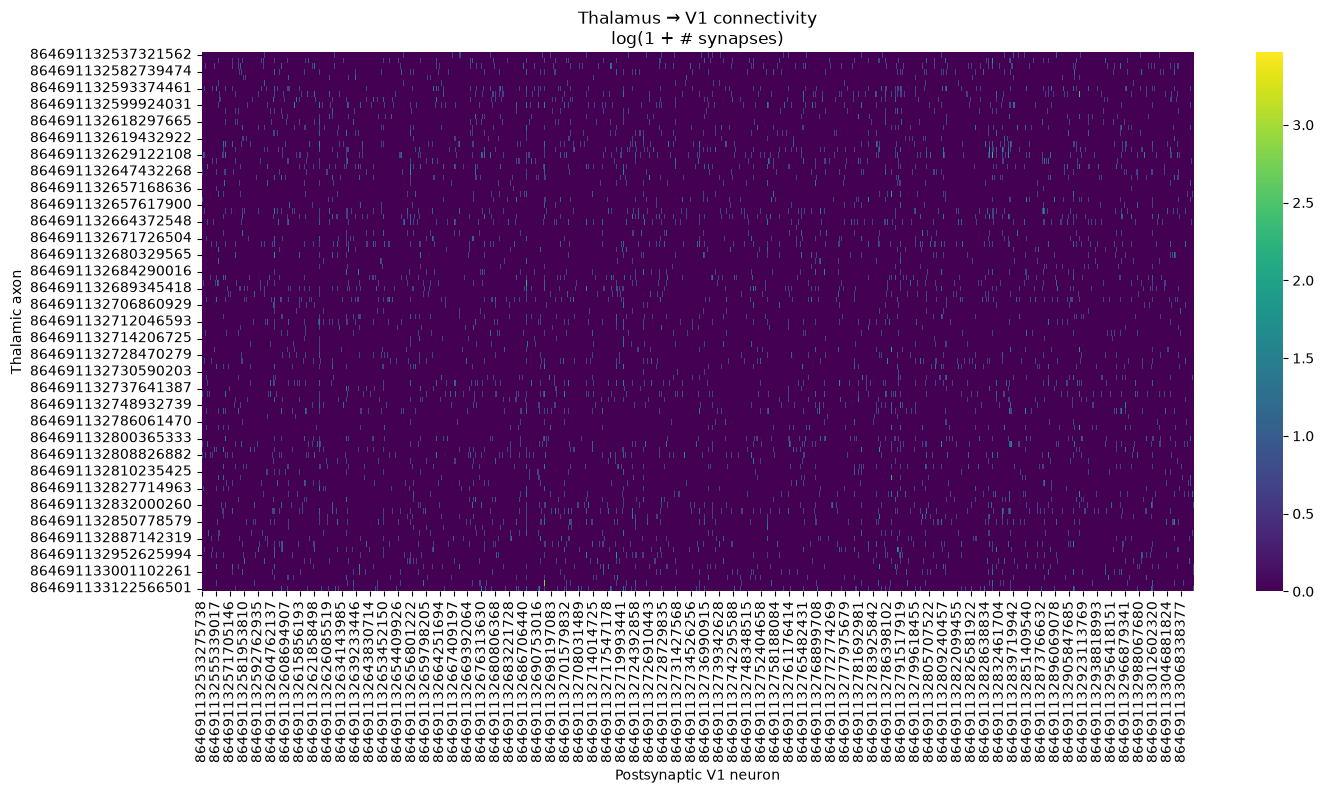

In [19]:
plt.figure(figsize=(16, 7))

sns.heatmap(
    np.log1p(conn_count),
    cmap="viridis",
)

plt.xlabel("Postsynaptic V1 neuron")
plt.ylabel("Thalamic axon")
plt.title("Thalamus → V1 connectivity\nlog(1 + # synapses)")

plt.show()

In [20]:
cell_types = client.materialize.query_table(
    "cell_type_multifeature_v1",
)

print(cell_types.columns)
cell_types[[
    "pt_root_id",
    "classification_system",
    "cell_type"
]].head()

Index(['id_ref', 'created_ref', 'valid_ref', 'volume', 'pt_supervoxel_id',
       'pt_root_id', 'id', 'created', 'valid', 'target_id',
       'classification_system', 'cell_type', 'pt_position',
       'bb_start_position', 'bb_end_position'],
      dtype='object')


,pt_root_id,classification_system,cell_type
0,864691132654552792,excitatory,L3IT
1,864691132773514104,excitatory,L2IT
2,864691132777373560,excitatory,L4IT
3,864691132802050269,excitatory,L5IT
4,864691132752568948,excitatory,L6CT


In [21]:
meta = cell_types[
    ["pt_root_id", "classification_system", "cell_type"]
].copy()

meta = meta[
    meta["pt_root_id"].isin(conn_count.columns)
].copy()

print(len(meta))

meta["layer"] = meta["cell_type"].str.extract(r"^(L[1-6])")

20149


In [22]:
meta["cell_type"]

0        L3IT
1        L2IT
2        L4IT
7        L6CT
8        L6CT
         ... 
48066    L6CT
48068    L3IT
48071    L3IT
48072    L4IT
48073    L6CT
Name: cell_type, Length: 20149, dtype: string

In [23]:
type_order = {
    "L2IT": 0,
    "L3IT": 1,
    "L4IT": 2,

    "L5IT": 3,
    "L5ET": 4,
    "L5NP": 5,

    "L6IT": 6,
    "L6CT": 7,
    "L6SP": 8,

    "PTC": 9,
    "DTC": 10,
    "STC": 11,
    "ITC": 12,
}

meta["type_order"] = meta["cell_type"].map(type_order)

In [24]:
meta_sorted = meta.sort_values(
    ["type_order", "pt_root_id"]
)

ordered_post_ids = meta_sorted["pt_root_id"].tolist()

conn_sorted = conn_count.loc[:, ordered_post_ids]

print(conn_sorted.shape)

# sorting function
def sort_connmatrix(connmatrix, meta_sorted):
    ordered_post_ids = meta_sorted["pt_root_id"].tolist()
    conn_sorted = conn_count.loc[:, ordered_post_ids]

    return conn_sorted
    

(97, 20149)


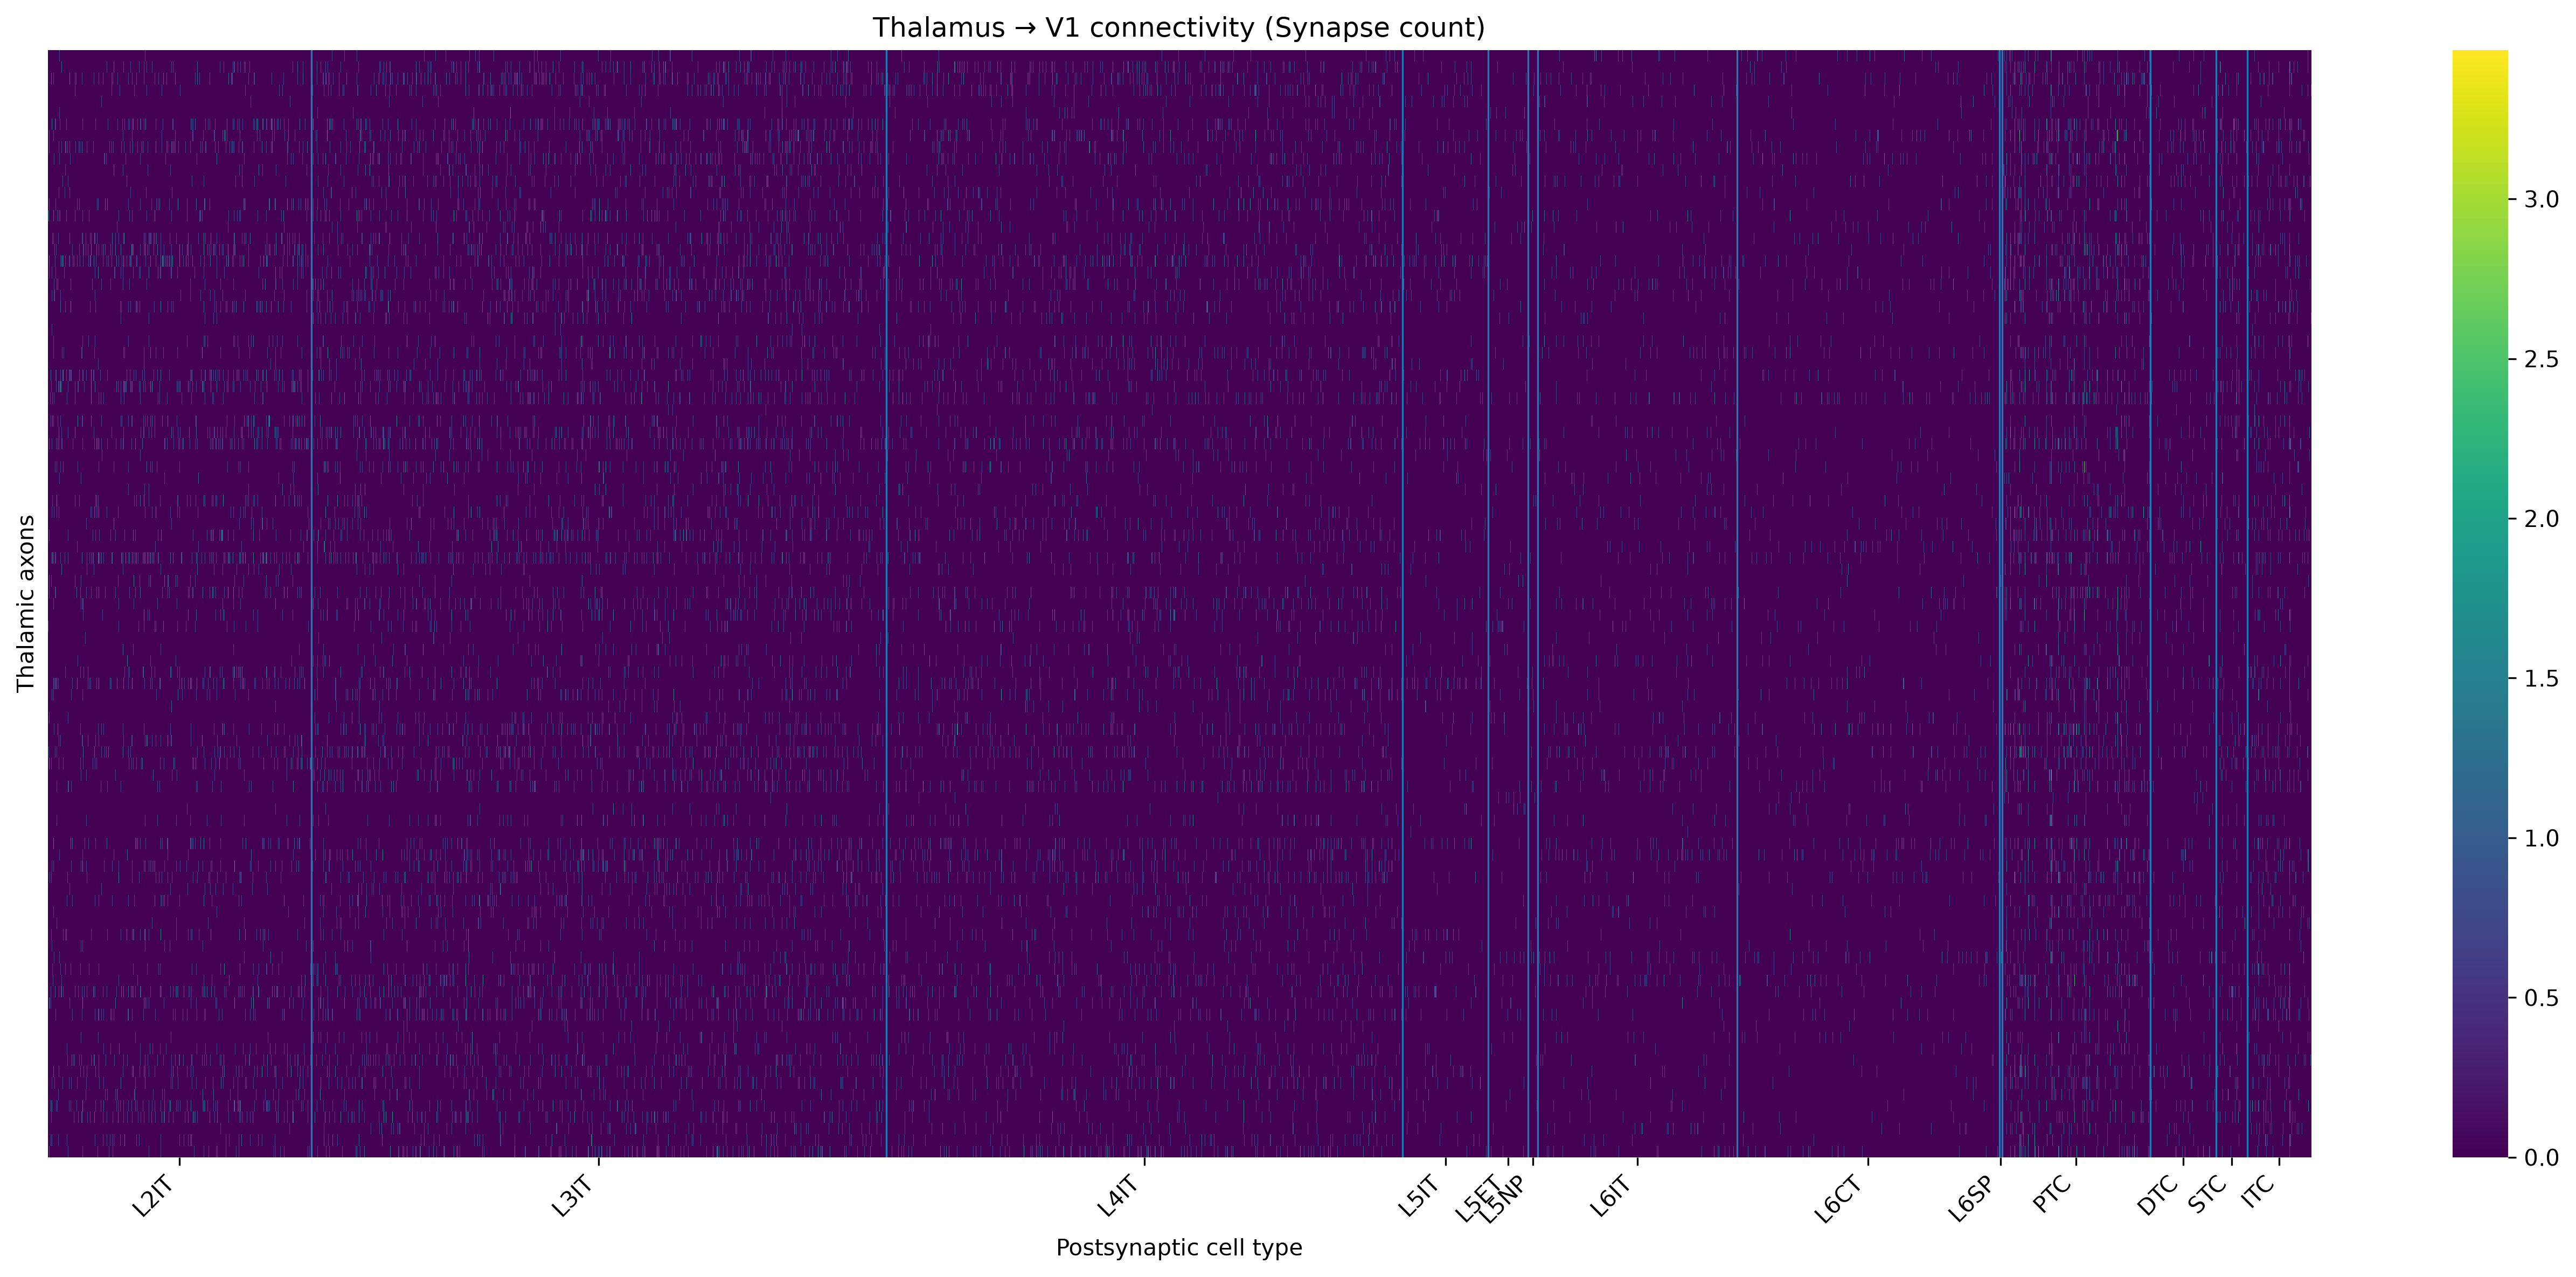

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

group_sizes = (
    meta_sorted
    .groupby("cell_type", sort=False)
    .size()
)

group_sizes

fig, ax = plt.subplots(figsize=(18, 8), dpi =300)

sns.heatmap(
    np.log1p(conn_sorted),
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

starts = np.r_[0, np.cumsum(group_sizes.values)[:-1]]
ends   = np.cumsum(group_sizes.values)

centers = (starts + ends) / 2

for x in ends[:-1]:
    ax.axvline(x, linewidth=0.8)

ax.set_xticks(centers)
ax.set_xticklabels(
    group_sizes.index,
    rotation=45,
    ha="right"
)

ax.set_xlabel("Postsynaptic cell type")
ax.set_ylabel("Thalamic axons")
ax.set_title("Thalamus → V1 connectivity (Synapse count)")

plt.tight_layout()
plt.show()

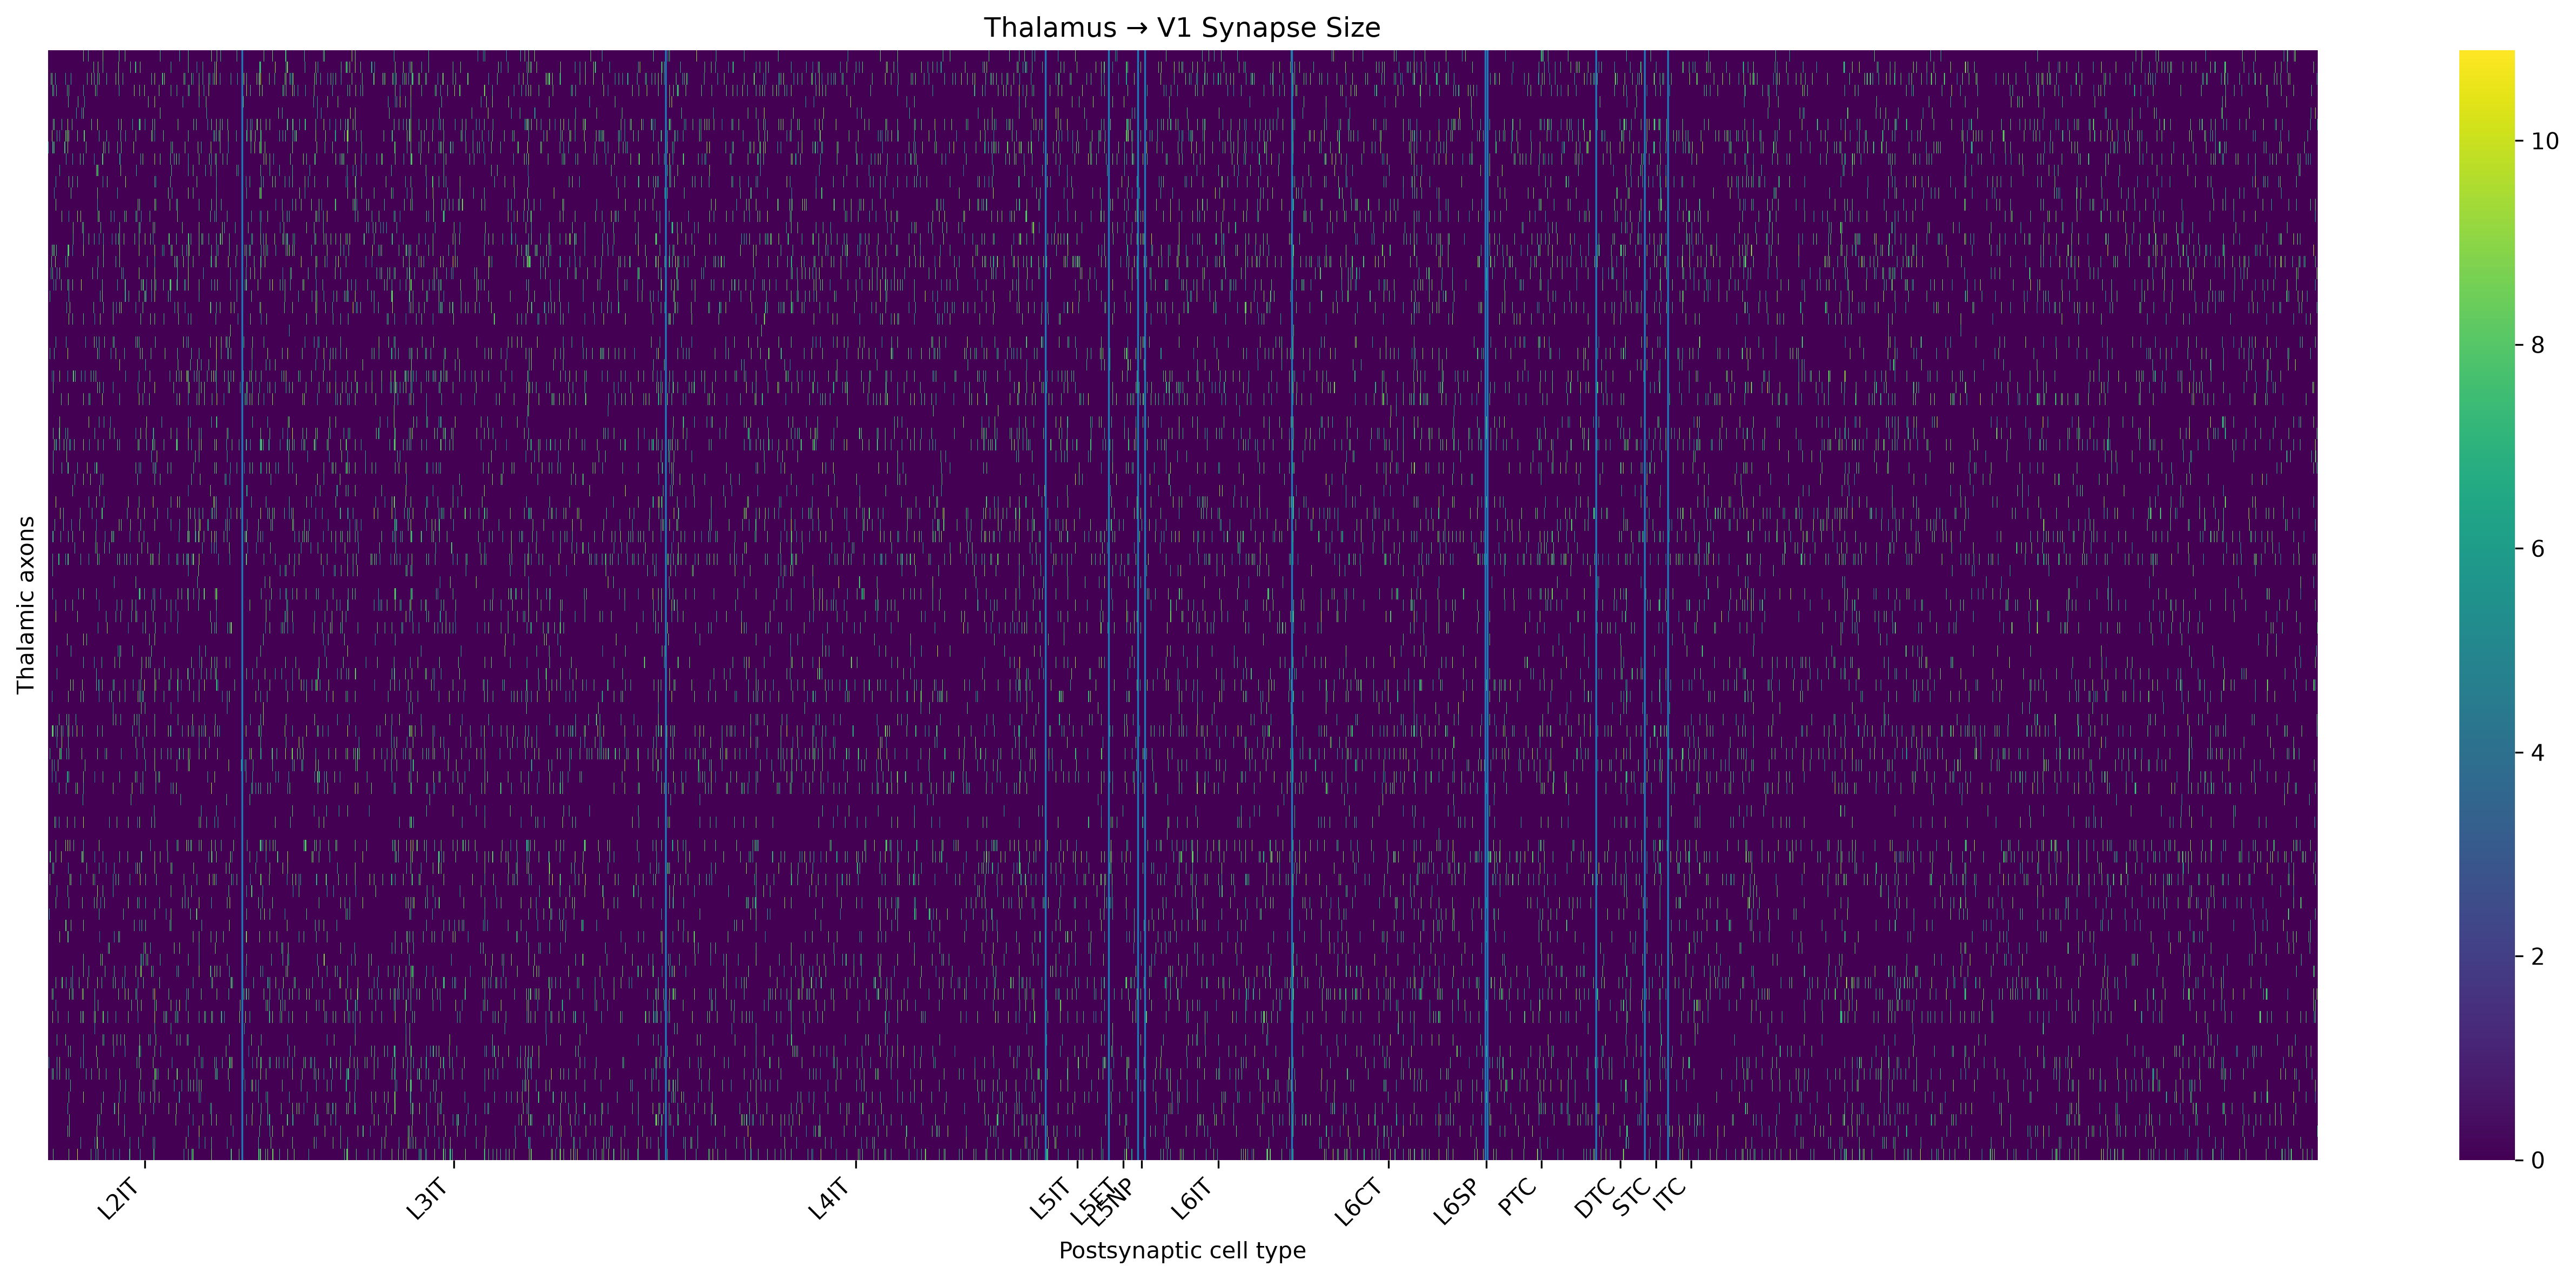

In [30]:
fig, ax = plt.subplots(figsize=(18, 8), dpi =300)

sns.heatmap(
    np.log1p(conn_size),
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

starts = np.r_[0, np.cumsum(group_sizes.values)[:-1]]
ends   = np.cumsum(group_sizes.values)

centers = (starts + ends) / 2

for x in ends[:-1]:
    ax.axvline(x, linewidth=0.8)

ax.set_xticks(centers)
ax.set_xticklabels(
    group_sizes.index,
    rotation=45,
    ha="right"
)

ax.set_xlabel("Postsynaptic cell type")
ax.set_ylabel("Thalamic axons")
ax.set_title("Thalamus → V1 Synapse Size")

plt.tight_layout()
plt.show()

## Micro circuit "motif" analysis

In [31]:
# merge the dataframe to label the cell type (E or I) of post-synaptice neurons

ct = cell_types[
    ["pt_root_id", "classification_system", "cell_type"]
].drop_duplicates("pt_root_id")

thal_typed = thal_syn.merge(
    ct,
    left_on="post_pt_root_id",
    right_on="pt_root_id",
    how="inner"
)

# dividing thal_syn into T->E and T -> I
T_E_syn = thal_typed[
    thal_typed["classification_system"] == "excitatory"
].copy()

T_I_syn = thal_typed[
    thal_typed["classification_system"] == "inhibitory"
].copy()

In [32]:
T_E_syn

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position,pt_root_id,classification_system,cell_type
0,324977225,2021-11-18 22:16:58.141699+00:00,NaN,True,739.0,89662287497449724,864691132804540262,89591918753323750,864691132612319611,[709739 598771 182340],[709341 598781 182655],[709555 598810 182430],864691132612319611,excitatory,L3IT
1,417826507,2021-11-19 02:10:08.767039+00:00,NaN,True,1808.0,93532774786769330,864691132843175686,93532774786771710,864691132612319611,[846732 606385 243180],[847130 606638 243405],[846926 606531 243270],864691132612319611,excitatory,L3IT
3,476172143,2021-11-18 22:03:58.345906+00:00,NaN,True,2091.0,95923938168793184,864691132932298216,95923938168801059,864691132682867247,[931403 556615 395100],[931423 557071 395415],[931588 556935 395100],864691132682867247,excitatory,L5IT
4,628525282,2021-11-18 22:31:26.037114+00:00,NaN,True,1393.0,101975993698675496,864691132645737598,101975993698685903,864691132619311425,[1145288 567944 385875],[1145182 567663 386100],[1145346 567770 386235],864691132619311425,excitatory,L3IT
5,336004024,2021-11-18 22:03:58.345906+00:00,NaN,True,2102.0,90435450464365032,864691132661526697,90435450464372637,864691132717537039,[737704 567013 225360],[737791 566935 225675],[737578 567168 225540],864691132717537039,excitatory,L3IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110288,562760033,2021-11-19 07:02:16.946095+00:00,NaN,True,2187.0,99170521463151080,864691132657282928,99170521463164554,864691132848766184,[1047241 904602 507825],[1046824 904253 507735],[1047047 904389 507870],864691132848766184,excitatory,L6CT
110290,432097798,2021-11-19 00:40:18.412715+00:00,NaN,True,5283.0,94519449503331350,864691132731716336,94519449503338875,864691132842860980,[881875 659425 397890],[882205 659803 398070],[882215 659570 398160],864691132842860980,excitatory,L4IT
110291,400168853,2021-11-19 00:27:55.774292+00:00,NaN,True,2630.0,92620042897998710,864691132731716336,92619974178505838,864691132644530230,[814615 679252 309690],[814266 679067 310185],[814305 679242 309960],864691132644530230,excitatory,L4IT
110292,307436428,2021-11-19 04:45:30.802793+00:00,NaN,True,903.0,89168607246386510,864691132549572162,89168607246380012,864691132609963587,[694083 557720 345555],[694345 557730 345285],[694044 557604 345330],864691132609963587,excitatory,L3IT


In [33]:
T_E_syn

,id,created,superceded_id,valid,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position,pt_root_id,classification_system,cell_type
0,324977225,2021-11-18 22:16:58.141699+00:00,NaN,True,739.0,89662287497449724,864691132804540262,89591918753323750,864691132612319611,[709739 598771 182340],[709341 598781 182655],[709555 598810 182430],864691132612319611,excitatory,L3IT
1,417826507,2021-11-19 02:10:08.767039+00:00,NaN,True,1808.0,93532774786769330,864691132843175686,93532774786771710,864691132612319611,[846732 606385 243180],[847130 606638 243405],[846926 606531 243270],864691132612319611,excitatory,L3IT
3,476172143,2021-11-18 22:03:58.345906+00:00,NaN,True,2091.0,95923938168793184,864691132932298216,95923938168801059,864691132682867247,[931403 556615 395100],[931423 557071 395415],[931588 556935 395100],864691132682867247,excitatory,L5IT
4,628525282,2021-11-18 22:31:26.037114+00:00,NaN,True,1393.0,101975993698675496,864691132645737598,101975993698685903,864691132619311425,[1145288 567944 385875],[1145182 567663 386100],[1145346 567770 386235],864691132619311425,excitatory,L3IT
5,336004024,2021-11-18 22:03:58.345906+00:00,NaN,True,2102.0,90435450464365032,864691132661526697,90435450464372637,864691132717537039,[737704 567013 225360],[737791 566935 225675],[737578 567168 225540],864691132717537039,excitatory,L3IT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110288,562760033,2021-11-19 07:02:16.946095+00:00,NaN,True,2187.0,99170521463151080,864691132657282928,99170521463164554,864691132848766184,[1047241 904602 507825],[1046824 904253 507735],[1047047 904389 507870],864691132848766184,excitatory,L6CT
110290,432097798,2021-11-19 00:40:18.412715+00:00,NaN,True,5283.0,94519449503331350,864691132731716336,94519449503338875,864691132842860980,[881875 659425 397890],[882205 659803 398070],[882215 659570 398160],864691132842860980,excitatory,L4IT
110291,400168853,2021-11-19 00:27:55.774292+00:00,NaN,True,2630.0,92620042897998710,864691132731716336,92619974178505838,864691132644530230,[814615 679252 309690],[814266 679067 310185],[814305 679242 309960],864691132644530230,excitatory,L4IT
110292,307436428,2021-11-19 04:45:30.802793+00:00,NaN,True,903.0,89168607246386510,864691132549572162,89168607246380012,864691132609963587,[694083 557720 345555],[694345 557730 345285],[694044 557604 345330],864691132609963587,excitatory,L3IT


In [34]:
TE = (
    T_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)

W_TE = TE.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

TE_size = (
    T_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("size")
    .reset_index()
)

W_TE_size = TE_size.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="size"
).fillna(0)


In [35]:
TE_size

,pre_pt_root_id,post_pt_root_id,size
0,864691132537321562,864691132546080145,1
1,864691132537321562,864691132549474370,1
2,864691132537321562,864691132557739017,1
3,864691132537321562,864691132558238729,1
4,864691132537321562,864691132560019172,1
...,...,...,...
69853,864691133122566501,864691133221362256,1
69854,864691133122566501,864691133227687504,1
69855,864691133122566501,864691133310556752,1
69856,864691133122566501,864691133310620752,1


In [36]:
TI = (
    T_I_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)


thal_recipient_I = TI["post_pt_root_id"].unique()

thal_recipient_I

array([864691132561636836, 864691132563533028, 864691132574637882, ...,
       864691132984526432, 864691133064998216, 864691133068459977],
      shape=(2752,))

In [37]:
proof = client.materialize.query_table(
    "proofreading_status_and_strategy",
    materialization_version=1196
)

proof_I = proof[
    (proof["status_axon"] == True) &
    (proof["pt_root_id"].isin(thal_recipient_I))
].copy()

I_ids = [
    int(x)
    for x in proof_I["pt_root_id"].dropna().unique()
]

len(I_ids)

416

In [38]:
proof

,id,created,superceded_id,valid,valid_id,status_dendrite,status_axon,strategy_dendrite,strategy_axon,pt_supervoxel_id,pt_root_id,pt_position
0,6647,2025-08-12 01:10:39.887222+00:00,<NA>,True,864691132960259431,False,True,none,axon_partially_extended,95650709462382392,864691132960259431,"[102548, 95052, 8477]"
1,6648,2025-08-12 01:10:39.936703+00:00,<NA>,True,864691132558727945,True,True,dendrite_extended,axon_fully_extended,91068013046529278,864691132558727945,"[84445, 59795, 3595]"
2,6649,2025-08-12 01:10:39.953614+00:00,<NA>,True,864691132753526759,True,True,dendrite_extended,axon_fully_extended,93250131310466182,864691132753526759,"[93085, 62735, 3317]"
3,6650,2025-08-12 01:10:39.969398+00:00,<NA>,True,864691132800365333,False,True,none,axon_partially_extended,94802642265494528,864691132800365333,"[99103, 80318, 7216]"
4,6651,2025-08-12 01:10:39.987704+00:00,<NA>,True,864691132666786211,True,True,dendrite_extended,axon_fully_extended,91356291586507183,864691132666786211,"[85515, 87118, 5747]"
...,...,...,...,...,...,...,...,...,...,...,...,...
3330,6642,2025-06-30 22:26:25.593589+00:00,<NA>,True,864691132656841334,True,False,dendrite_clean,none,94514845231677051,864691132656841334,"[98086, 54794, 8637]"
3331,6643,2025-06-30 22:26:25.594204+00:00,<NA>,True,864691132754687020,True,False,dendrite_clean,none,92480885890299849,864691132754687020,"[90015, 81850, 6180]"
3332,6644,2025-06-30 22:26:25.594832+00:00,<NA>,True,864691132717067995,True,False,dendrite_clean,none,95571132107152116,864691132717067995,"[102147, 58010, 7050]"
3333,6645,2025-06-30 22:26:25.595593+00:00,<NA>,True,864691132611857531,True,False,dendrite_clean,none,94022607015925148,864691132611857531,"[95999, 56406, 4106]"


In [36]:
# # getting I-> E Synapses
# from tqdm.auto import tqdm

# I_syn_list = []

# for i_id in tqdm(I_ids):

#     try:
#         tmp = client.materialize.query_table(
#             "synapses_v1dd",
#             filter_equal_dict={
#                 "pre_pt_root_id": i_id
#             },
#             select_columns=[
#                 "id",
#                 "pre_pt_root_id",
#                 "post_pt_root_id",
#                 "size",
#             ],
#         )

#         I_syn_list.append(tmp)

#     except Exception as e:
#         print("FAILED:", i_id, e)

# I_syn = pd.concat(I_syn_list, ignore_index=True)

# I_syn.to_csv('I_syn.csv', index=False)

In [37]:
I_syn = pd.read_csv('I_syn.csv')

In [38]:
I_syn

,id,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,size
0,372218216,91703462315921779,864691132717868815,91703462315904219,864691131243211248,578.0
1,338306638,90085668260813288,864691132717868815,90085599541323072,864691132730273515,390.0
2,366336515,91213011544620209,864691132717868815,91283380288821207,864691132810096417,483.0
3,368527651,91351893674486788,864691132717868815,91351893674471168,864691132761819444,810.0
4,465365238,95224098480827796,864691132717868815,95224098480827742,864691132800063765,991.0
...,...,...,...,...,...,...
2045662,473963807,96142122104937997,864691133311980112,96142122104920411,864691132730988676,1154.0
2045663,491042510,96277568126728612,864691133311980112,96277568126737942,864691132657192444,1961.0
2045664,491047995,96558768225666773,864691133311980112,96558768225671974,864691132634823509,1407.0
2045665,474709248,95853019132350176,864691133311980112,95853019132363102,864691132634823509,2023.0


In [39]:
#i'm interested in those with synaptic target = E
I_syn_typed = I_syn.merge(
    ct,
    left_on="post_pt_root_id",
    right_on="pt_root_id",
    how="inner"
)

I_E_syn = I_syn_typed[
    I_syn_typed["classification_system"] == "excitatory"
].copy()

In [40]:
W_TI = TI.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

IE = (
    I_E_syn
    .groupby(["pre_pt_root_id", "post_pt_root_id"])
    .size()
    .rename("n_synapses")
    .reset_index()
)

W_IE = IE.pivot(
    index="pre_pt_root_id",
    columns="post_pt_root_id",
    values="n_synapses"
).fillna(0)

In [41]:
common_I = W_TI.columns.intersection(W_IE.index)

W_TI2 = W_TI.loc[:, common_I]
W_IE2 = W_IE.loc[common_I, :]

A = (W_TI2 > 0).astype(int)
B = (W_IE2 > 0).astype(int)

FFI_paths = A @ B

In [ ]:
x

In [43]:
meta_sorted.shape

(20149, 5)

In [44]:
Direct.shape

(97, 15970)

In [45]:
FFI.shape

(97, 15970)

In [46]:
E_meta = ct[
    ct["classification_system"] == "excitatory"
][
    ["pt_root_id", "cell_type"]
].drop_duplicates("pt_root_id").copy()

E_meta["layer"] = E_meta["cell_type"].str.extract(r"^(L[2-6])")

common_E = Direct.columns.intersection(FFI.columns)

Direct_common = Direct.loc[:, common_E]
FFI_common = FFI.loc[:, common_E]

E_meta_common = E_meta[
    E_meta["pt_root_id"].isin(common_E)
].copy()

layer_order = {
    "L2": 0,
    "L3": 1,
    "L4": 2,
    "L5": 3,
    "L6": 4,
}

E_meta_common["layer_order"] = (
    E_meta_common["layer"].map(layer_order)
)

celltype_order = {
    "L2IT": 0,
    "L3IT": 0,
    "L4IT": 0,

    "L5IT": 0,
    "L5ET": 1,
    "L5NP": 2,

    "L6IT": 0,
    "L6CT": 1,
    "L6SP": 2,
}

E_meta_common["celltype_order"] = (
    E_meta_common["cell_type"].map(celltype_order)
)

In [47]:
E_meta_sorted = E_meta_common.sort_values(
    ["layer_order", "celltype_order", "pt_root_id"]
)

ordered_E = E_meta_sorted["pt_root_id"].tolist()

Direct_sorted = Direct_common.loc[:, ordered_E]
FFI_sorted = FFI_common.loc[:, ordered_E]

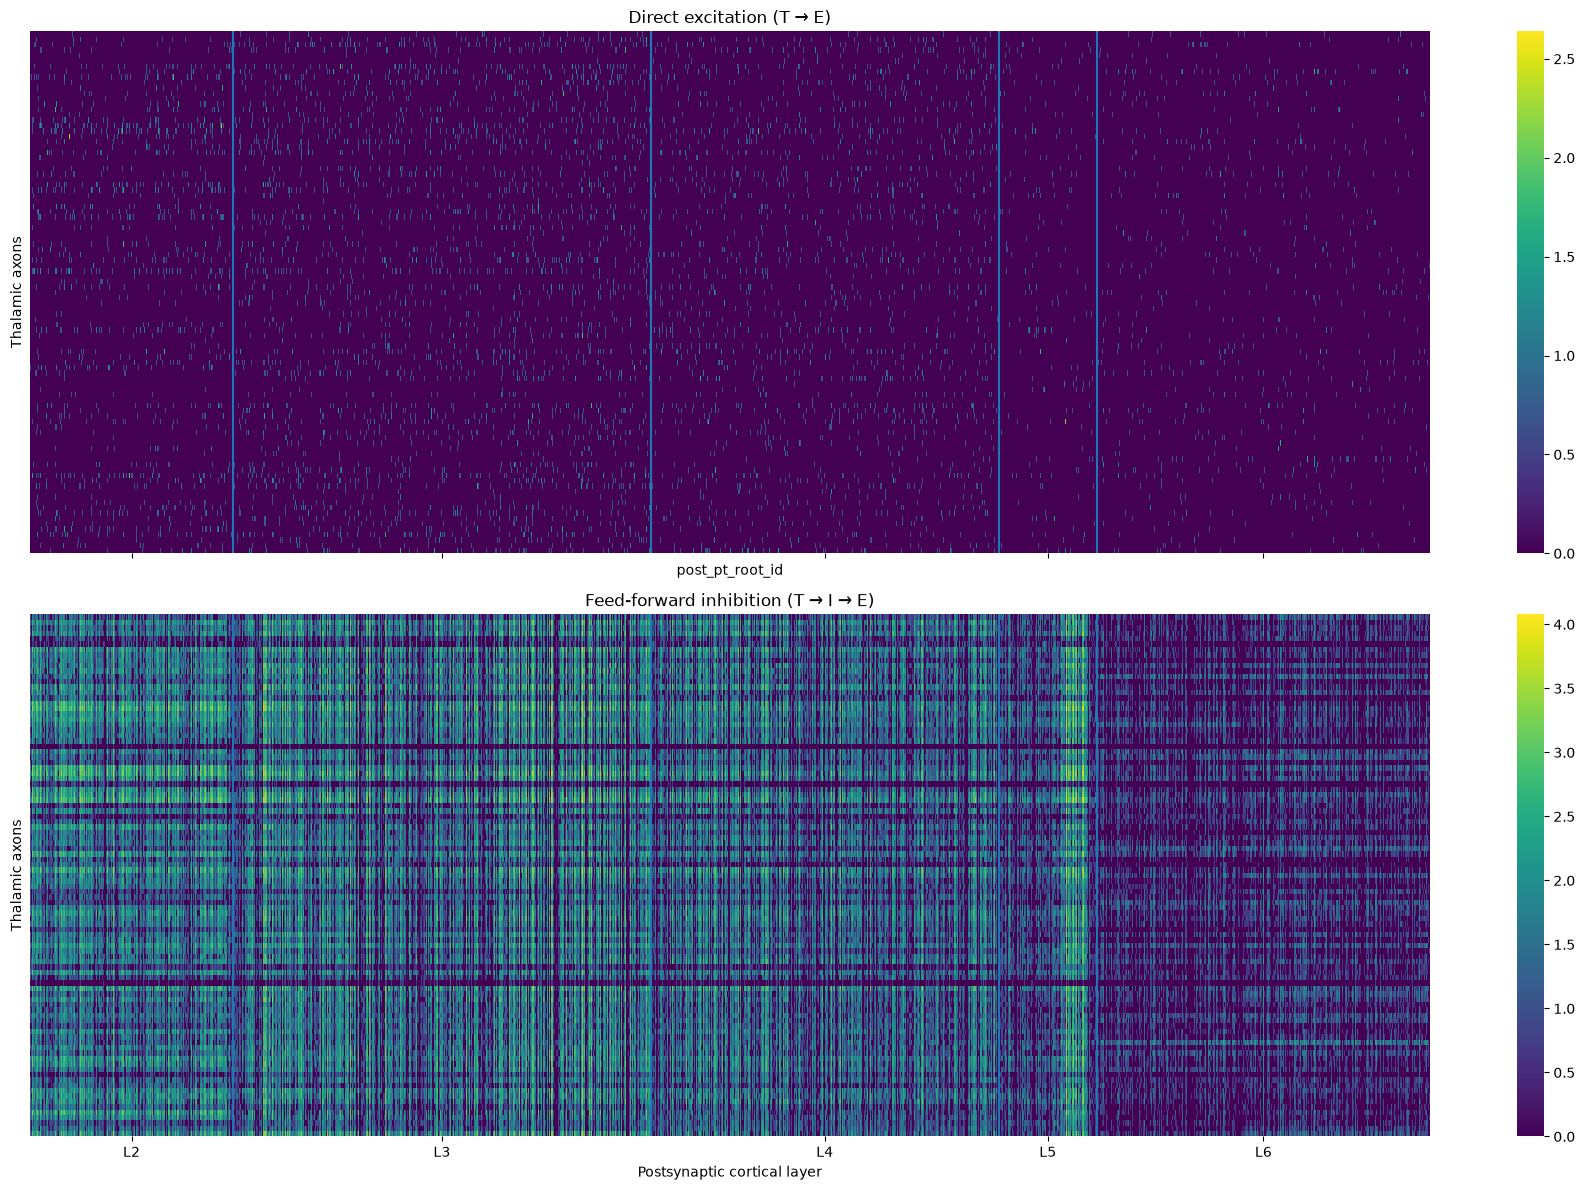

In [48]:
layer_sizes = (
    E_meta_sorted
    .groupby("layer", sort=False)
    .size()
)

boundaries = np.cumsum(layer_sizes.values)

starts = np.r_[0, boundaries[:-1]]
centers = (starts + boundaries) / 2

fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 12),
    sharex=True
)

sns.heatmap(
    np.log1p(Direct_sorted),
    ax=axes[0],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

sns.heatmap(
    np.log1p(FFI_sorted),
    ax=axes[1],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

for ax in axes:
    for x in boundaries[:-1]:
        ax.axvline(
            x,
            linewidth=1.5,
        )

axes[1].set_xticks(centers)
axes[1].set_xticklabels(
    layer_sizes.index,
    rotation=0
)

axes[0].set_title("Direct excitation (T → E)")
axes[1].set_title("Feed-forward inhibition (T → I → E)")

axes[0].set_ylabel("Thalamic axons")
axes[1].set_ylabel("Thalamic axons")
axes[1].set_xlabel("Postsynaptic cortical layer")

plt.tight_layout()
plt.show()

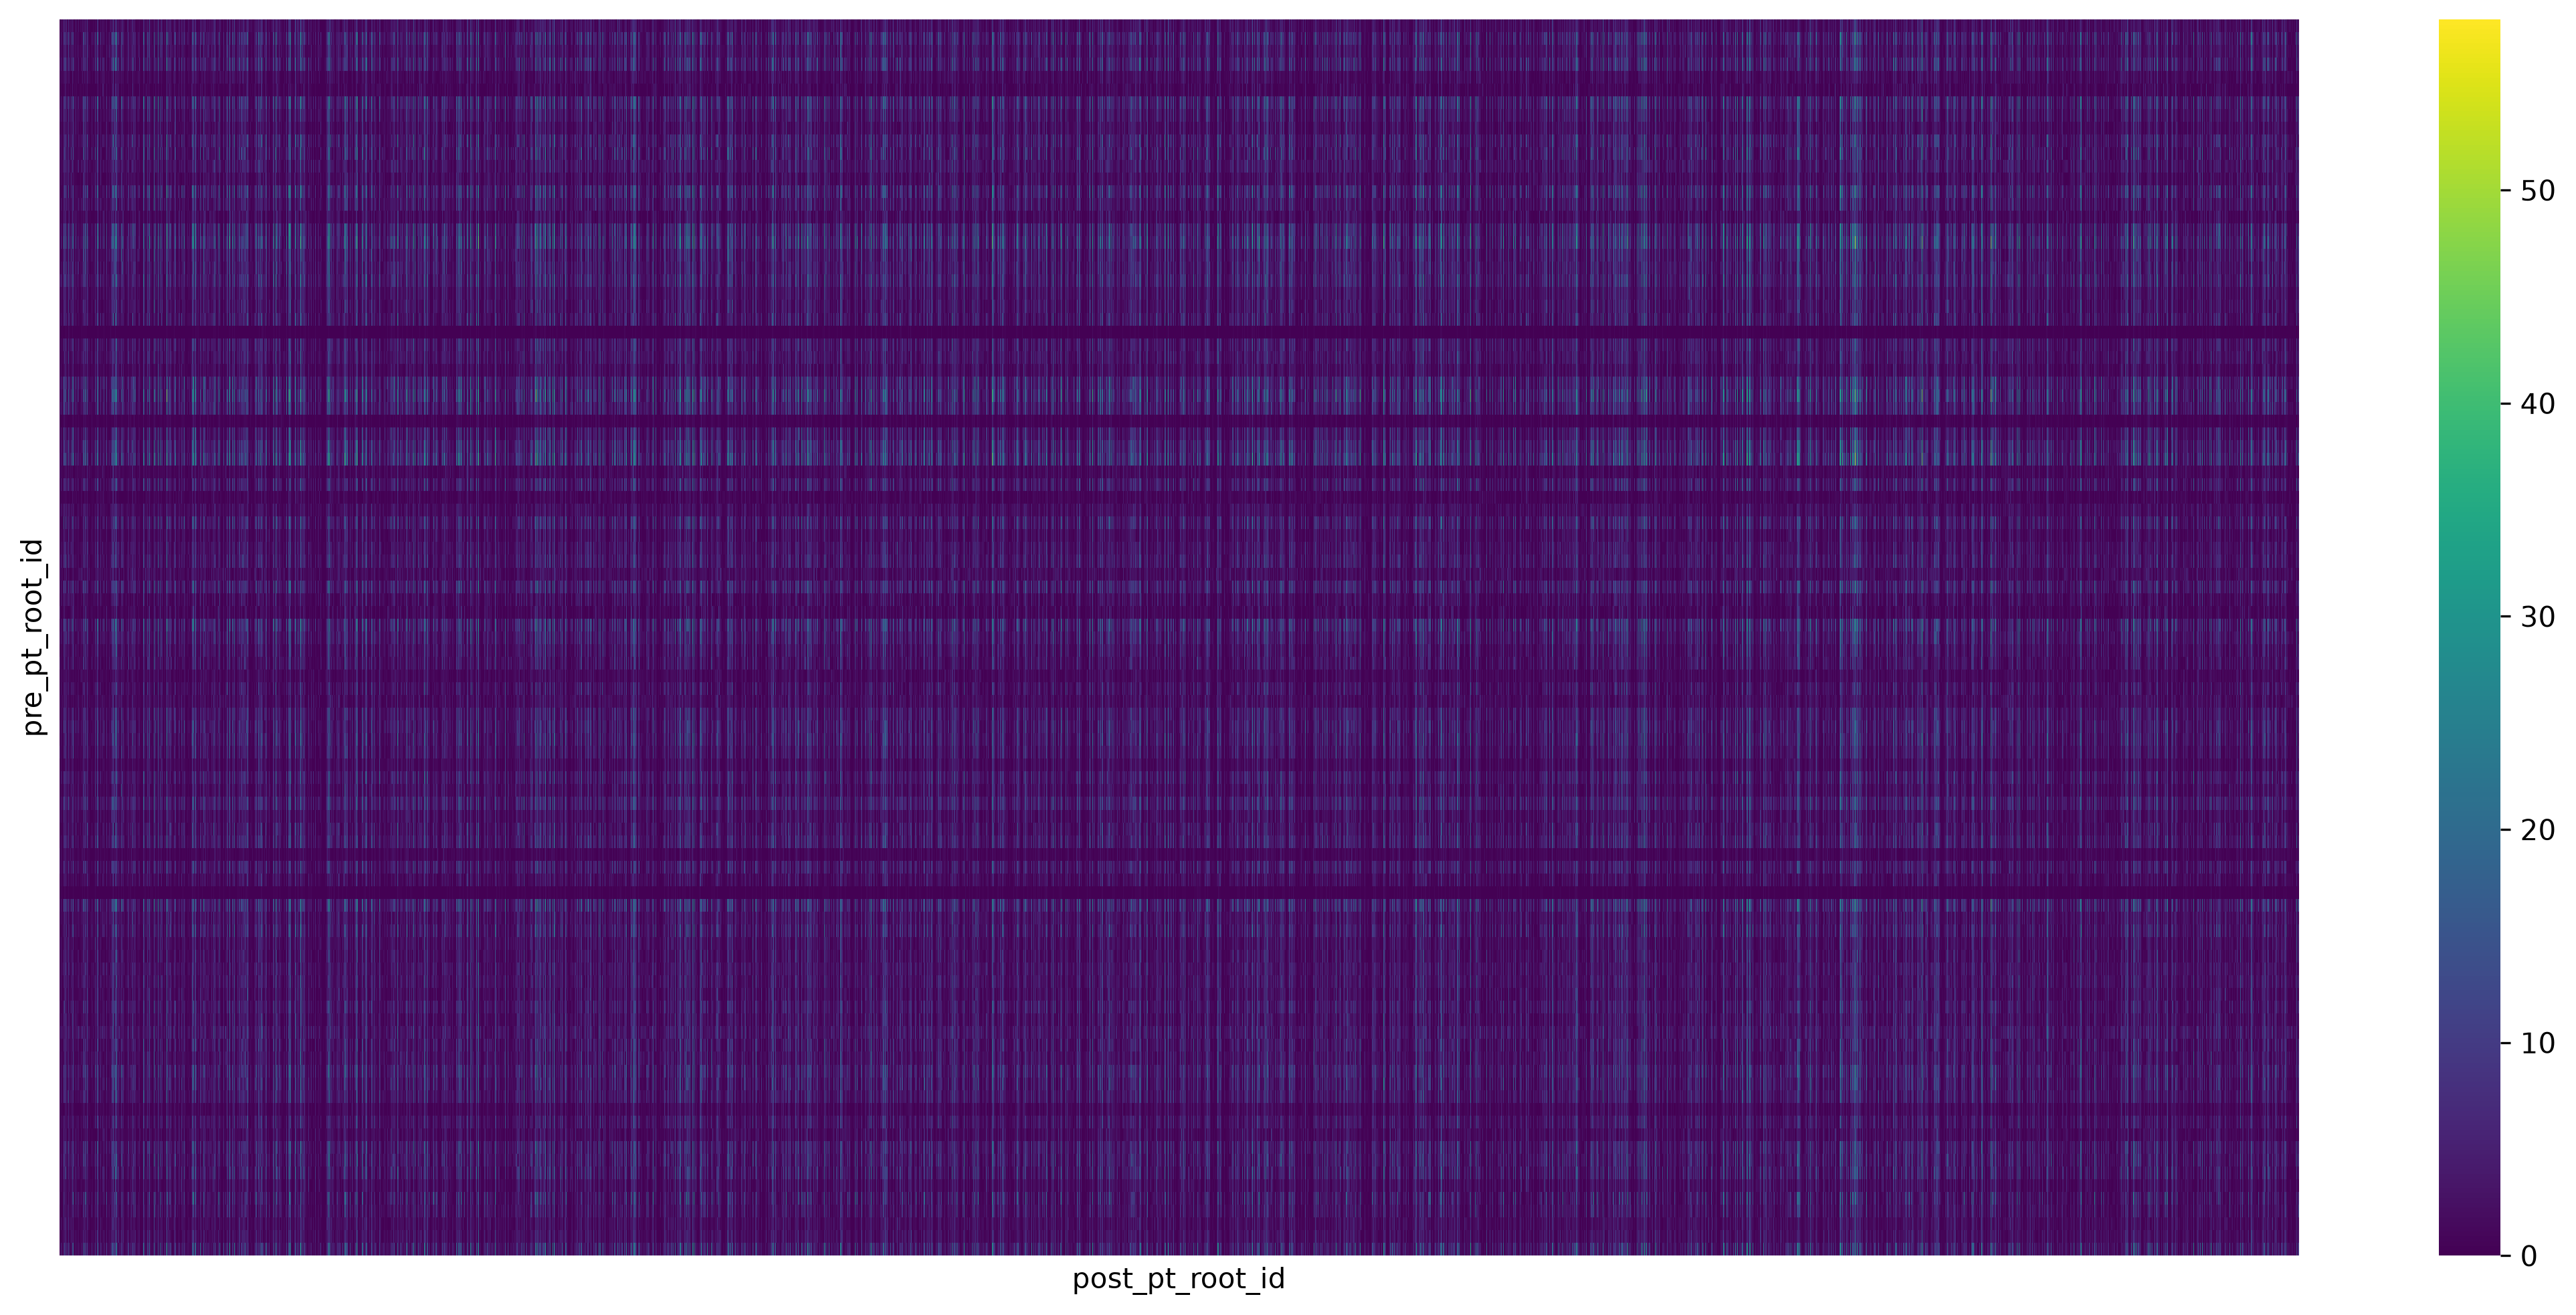

In [49]:
fig, ax = plt.subplots(figsize=(18, 8), dpi =300)


sns.heatmap(
    FFI,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

plt.show()

In [50]:
#sanity check
print(FFI.shape)
print(Direct.shape) #should be matched

(97, 15970)
(97, 15970)


In [ ]:
direct_connected = Direct > 0
ffi_connected = FFI > 0

both = direct_connected & ffi_connected

fraction_direct_with_ffi = (
    both.sum().sum() /
    direct_connected.sum().sum()
)

print(fraction_direct_with_ffi) #if you have direct excitation with 90% probability you will have inhiibtion

0.9123389501829027


In [51]:
direct_binary = Direct > 0
ffi_binary = FFI > 0

p_ffi_given_direct = (
    (direct_binary & ffi_binary).sum(axis=0)
    /
    direct_binary.sum(axis=0).replace(0, np.nan)
)

In [52]:
p_ffi_given_direct.describe()

count    15970.000000
mean         0.787387
std          0.377625
min          0.000000
25%          0.714286
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64

In [53]:
n_direct_sources = direct_binary.sum(axis=0)

check_df = pd.DataFrame({
    "p_ffi_given_direct": p_ffi_given_direct,
    "n_direct_sources": n_direct_sources
})

check_df["n_direct_sources"].describe()

count    15970.000000
mean         4.262304
std          3.807144
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max         26.000000
Name: n_direct_sources, dtype: float64

Text(0, 0.5, 'P(FFI | direct)')

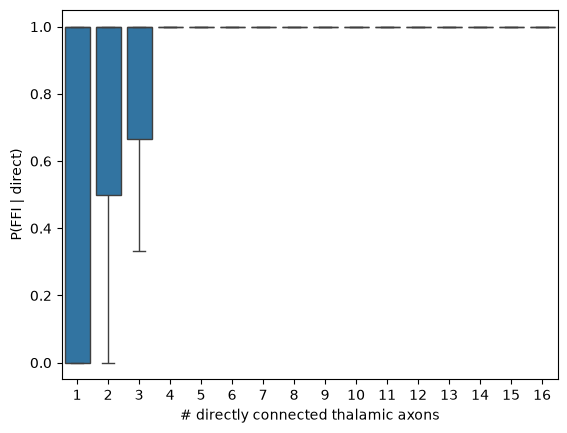

In [54]:
sns.boxplot(
    data=check_df,
    x="n_direct_sources",
    y="p_ffi_given_direct",
    showfliers=False
)

plt.xlim(-0.5, 15.5)
plt.xlabel("# directly connected thalamic axons")
plt.ylabel("P(FFI | direct)")

In [55]:
print(
    "fraction p=1:",
    (p_ffi_given_direct == 1).mean()
)

print(
    "fraction p=0:",
    (p_ffi_given_direct == 0).mean()
)

print(
    "fraction p>=0.8:",
    (p_ffi_given_direct >= 0.8).mean()
)

fraction p=1: 0.7184721352536005
fraction p=0: 0.16524733876017533
fraction p>=0.8: 0.7379461490294302


In [56]:
direct_binary = Direct > 0
ffi_binary = FFI > 0

n_direct = direct_binary.sum(axis=0)

n_direct_with_ffi = (
    direct_binary & ffi_binary
).sum(axis=0)

check_df = pd.DataFrame({
    "n_direct": n_direct,
    "n_direct_with_ffi": n_direct_with_ffi,
    "p_ffi_given_direct": p_ffi_given_direct
})

In [57]:
check_df.groupby("n_direct")["p_ffi_given_direct"].agg(
    ["count", "mean", "median"]
).head(20)

,count,mean,median
n_direct,,,
1,4517,0.557228,1.0
2,2729,0.708501,1.0
3,1849,0.831981,1.0
4,1358,0.890832,1.0
5,1076,0.932900,1.0
6,876,0.958714,1.0
7,736,0.981561,1.0
8,582,0.984107,1.0
9,520,0.992521,1.0


In [59]:
# comparison between layers
E_meta = ct[
    ct["classification_system"] == "excitatory"
].copy()

E_meta["layer"] = E_meta["cell_type"].str.extract(r"^(L[2-6])")

per_E = pd.DataFrame({
    "direct_synapses": Direct.sum(axis=0),
    "n_ffi_paths": FFI.sum(axis=0),
})

per_E.index.name = "pt_root_id"

per_E = per_E.merge(
    E_meta[
        ["pt_root_id", "layer", "cell_type"]
    ],
    left_index=True,
    right_on="pt_root_id",
    how="left"
)

In [ ]:
per_E

,direct_synapses,n_ffi_paths,pt_root_id,layer,cell_type
24341,4.0,122,864691132533275738,L4,L4IT
29429,18.0,1058,864691132533347418,L4,L4IT
16091,6.0,52,864691132533614170,L4,L4IT
39922,1.0,25,864691132533623130,L2,L2IT
24392,8.0,667,864691132533624410,L2,L2IT
...,...,...,...,...,...
9334,3.0,28,864691133314112336,L4,L4IT
41132,14.0,666,864691133314166096,L2,L2IT
16590,1.0,147,864691133314201424,L5,L5ET
3233,4.0,171,864691133314222928,L4,L4IT


In [ ]:
direct_per_E = Direct_sorted.sum(axis=0)

direct_layer = (
    E_meta_sorted
    .assign(
        direct_strength=
        E_meta_sorted["pt_root_id"].map(direct_per_E)
    )
    .groupby("layer")["direct_strength"]
    .agg(["mean", "median", "sum", "count"])
)

ffi_per_E = FFI_sorted.sum(axis=0)

ffi_layer = (
    E_meta_sorted
    .assign(
        ffi_strength=
        E_meta_sorted["pt_root_id"].map(ffi_per_E)
    )
    .groupby("layer")["ffi_strength"]
    .agg(["mean", "median", "sum", "count"])
)

In [ ]:
ffi_layer

,mean,median,sum,count
layer,,,,
L2,448.923210,401.0,1040604,2318
L3,468.774932,344.0,2232775,4763
L4,342.835516,254.0,1361057,3970
L5,294.806971,187.0,329889,1119
L6,97.766053,69.0,371511,3800


In [ ]:
direct_layer

,mean,median,sum,count
layer,,,,
L2,6.251510,5.0,14491.0,2318
L3,7.399748,6.0,35245.0,4763
L4,5.611587,4.0,22278.0,3970
L5,2.443253,1.0,2734.0,1119
L6,2.251316,2.0,8555.0,3800


In [ ]:
print("Direct shape:", Direct_sorted.shape)
print("FFI shape:", FFI_sorted.shape)

print("Direct density:",
      (Direct_sorted > 0).values.mean())

print("FFI density:",
      (FFI_sorted > 0).values.mean())

print("number of intermediary I:", len(common_I))

print("TI density:",
      (W_TI2 > 0).values.mean())

print("IE density:",
      (W_IE2 > 0).values.mean())

Direct shape: (97, 15970)
FFI shape: (97, 15970)
Direct density: 0.04394128165568172
FFI density: 0.6858600855986418
number of intermediary I: 415
TI density: 0.12751211029685752
IE density: 0.039563305777045116


In [ ]:
n_I_per_T = (W_TI2 > 0).sum(axis=1)

n_I_per_T.describe()

count     97.000000
mean      52.917526
std       23.485221
min        2.000000
25%       37.000000
50%       51.000000
75%       70.000000
max      116.000000
dtype: float64

In [ ]:
n_E_per_I = (W_IE2 > 0).sum(axis=1)

n_E_per_I.describe()

count     415.000000
mean     1072.759036
std       786.221748
min         7.000000
25%       340.500000
50%      1007.000000
75%      1723.000000
max      3440.000000
dtype: float64

In [ ]:
Direct_binary = (Direct_sorted > 0)

FFI_on_direct = FFI_sorted.where(
    Direct_binary,
    0
)

Text(0.5, 1.0, 'FFI onto directly excited targets (T → I → E)')

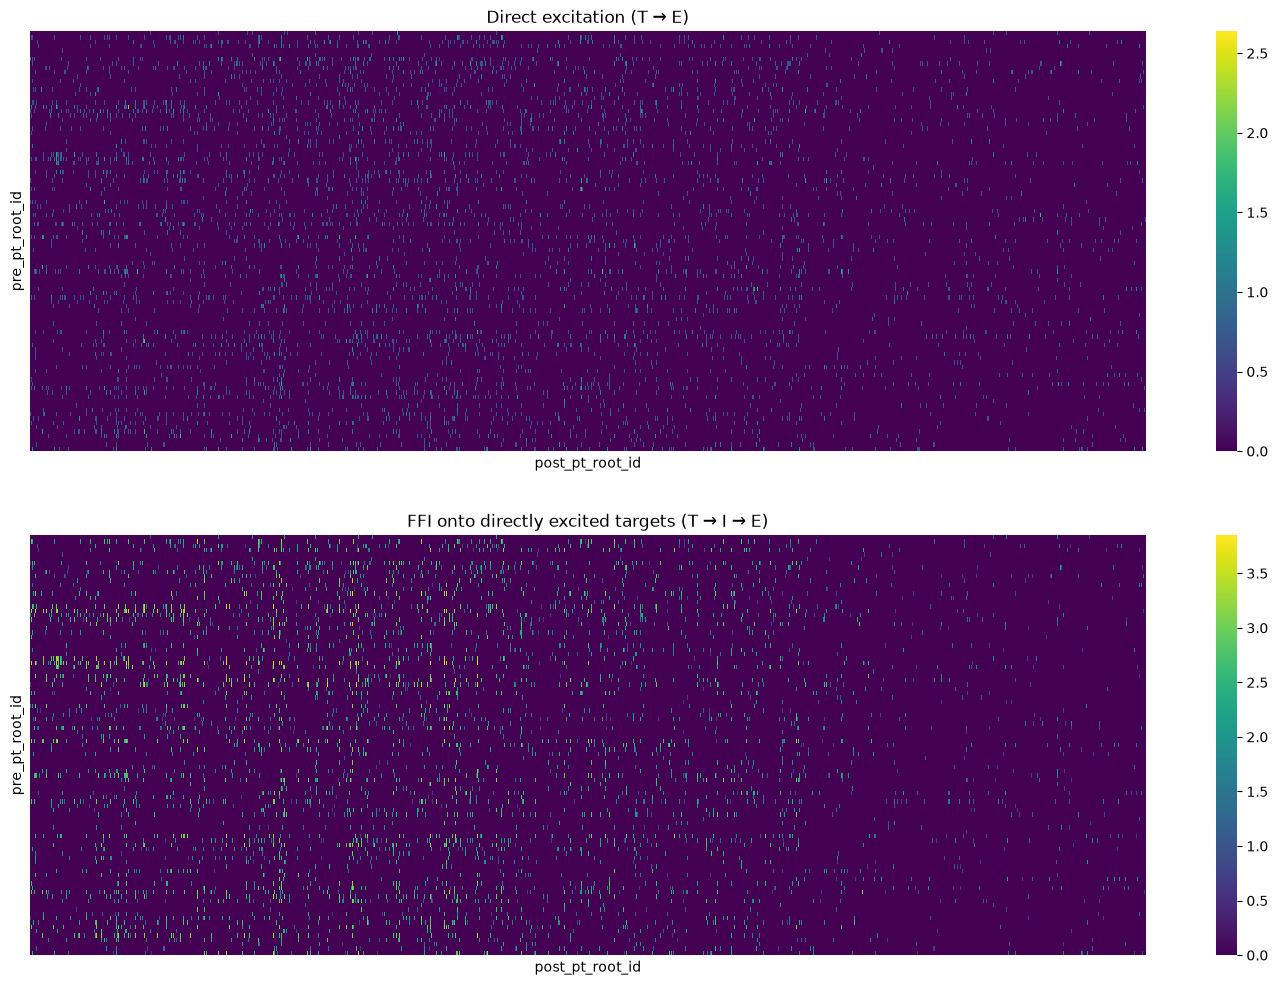

In [ ]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 12),
    sharex=True
)

sns.heatmap(
    np.log1p(Direct_sorted),
    ax=axes[0],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

sns.heatmap(
    np.log1p(FFI_on_direct),
    ax=axes[1],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

axes[0].set_title("Direct excitation (T → E)")
axes[1].set_title(
    "FFI onto directly excited targets (T → I → E)"
)

/tmp/ipykernel_36939/3083617154.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cell_type", sort=False)


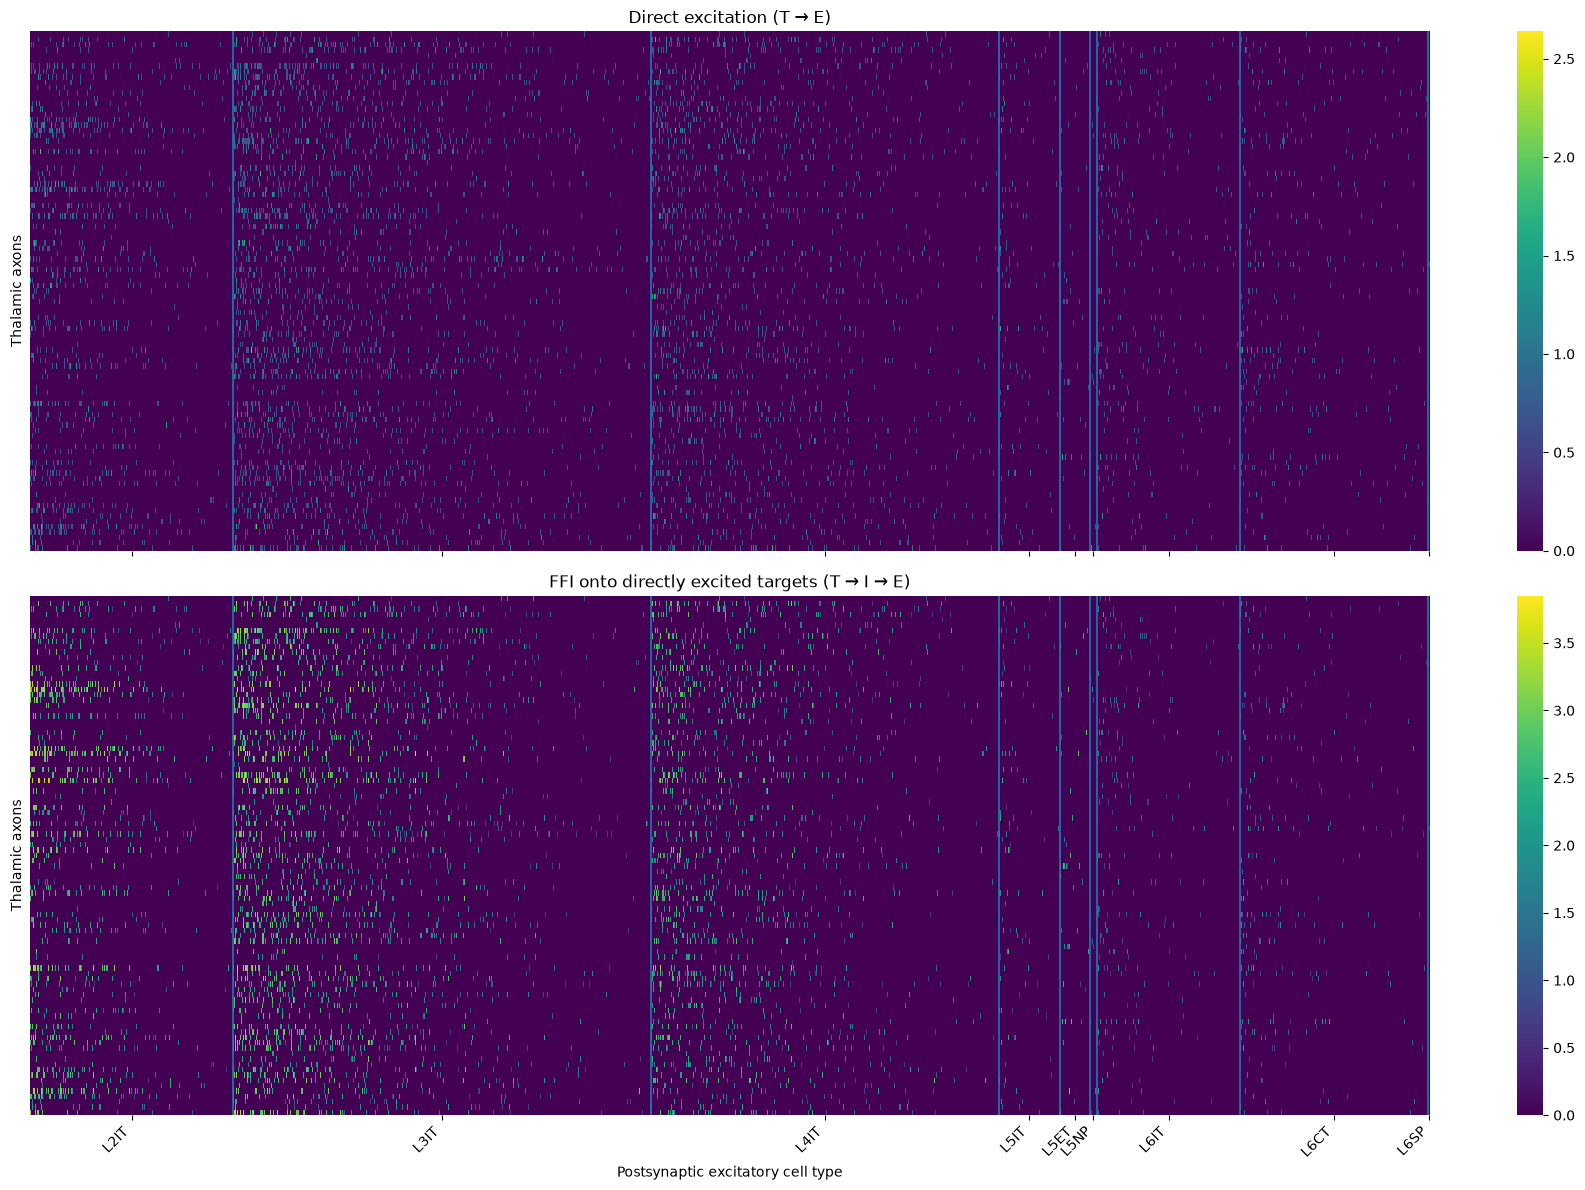

In [ ]:
common_E = Direct.columns.intersection(FFI_on_direct.columns)

Direct_common = Direct.loc[:, common_E]
FFI_common = FFI_on_direct.loc[:, common_E]

E_meta = ct[
    ct["classification_system"] == "excitatory"
][["pt_root_id", "cell_type"]].drop_duplicates("pt_root_id").copy()

E_meta_common = E_meta[
    E_meta["pt_root_id"].isin(common_E)
].copy()

E_meta_common["cell_type"] = pd.Categorical(
    E_meta_common["cell_type"],
    categories=celltype_order,
    ordered=True
)

direct_strength = Direct_common.sum(axis=0)

E_meta_common["direct_strength"] = (
    E_meta_common["pt_root_id"].map(direct_strength)
)

E_meta_sorted = E_meta_common.sort_values(
    ["cell_type", "direct_strength", "pt_root_id"],
    ascending=[True, False, True]
)

ordered_E = E_meta_sorted["pt_root_id"].tolist()

Direct_ct_sorted = Direct_common.loc[:, ordered_E]
FFI_ct_sorted = FFI_common.loc[:, ordered_E]

group_sizes = (
    E_meta_sorted
    .groupby("cell_type", sort=False)
    .size()
)

boundaries = np.cumsum(group_sizes.values)
starts = np.r_[0, boundaries[:-1]]
centers = (starts + boundaries) / 2

fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 12),
    sharex=True
)

sns.heatmap(
    np.log1p(Direct_ct_sorted),
    ax=axes[0],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

sns.heatmap(
    np.log1p(FFI_ct_sorted),
    ax=axes[1],
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

# 境界線
for ax in axes:
    for x in boundaries[:-1]:
        ax.axvline(x, linewidth=1.2)

axes[0].set_title("Direct excitation (T → E)")
axes[1].set_title("FFI onto directly excited targets (T → I → E)")

axes[0].set_ylabel("Thalamic axons")
axes[1].set_ylabel("Thalamic axons")
axes[1].set_xlabel("Postsynaptic excitatory cell type")

axes[1].set_xticks(centers)
axes[1].set_xticklabels(group_sizes.index, rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Statistics across layers 

In [ ]:
# 1. neuronごとに、thalamic axons across の平均を計算
direct_mean_per_E = Direct_ct_sorted.mean(axis=0)
ffi_mean_per_E = FFI_ct_sorted.mean(axis=0)

# 2. DataFrameにする
plot_df = pd.DataFrame({
    "pt_root_id": Direct_ct_sorted.columns,
    "Direct": direct_mean_per_E.values,
    "FFI": ffi_mean_per_E.values,
})

# cell type metadata を付ける
plot_df = plot_df.merge(
    E_meta[["pt_root_id", "cell_type"]],
    on="pt_root_id",
    how="left"
)

plot_df.head()

,pt_root_id,Direct,FFI,cell_type
0,864691132830603164,0.381443,2.958763,L2IT
1,864691132754303779,0.309278,3.041237,L2IT
2,864691132740320963,0.298969,2.288660,L2IT
3,864691132808654841,0.298969,2.773196,L2IT
4,864691132641514406,0.278351,2.391753,L2IT


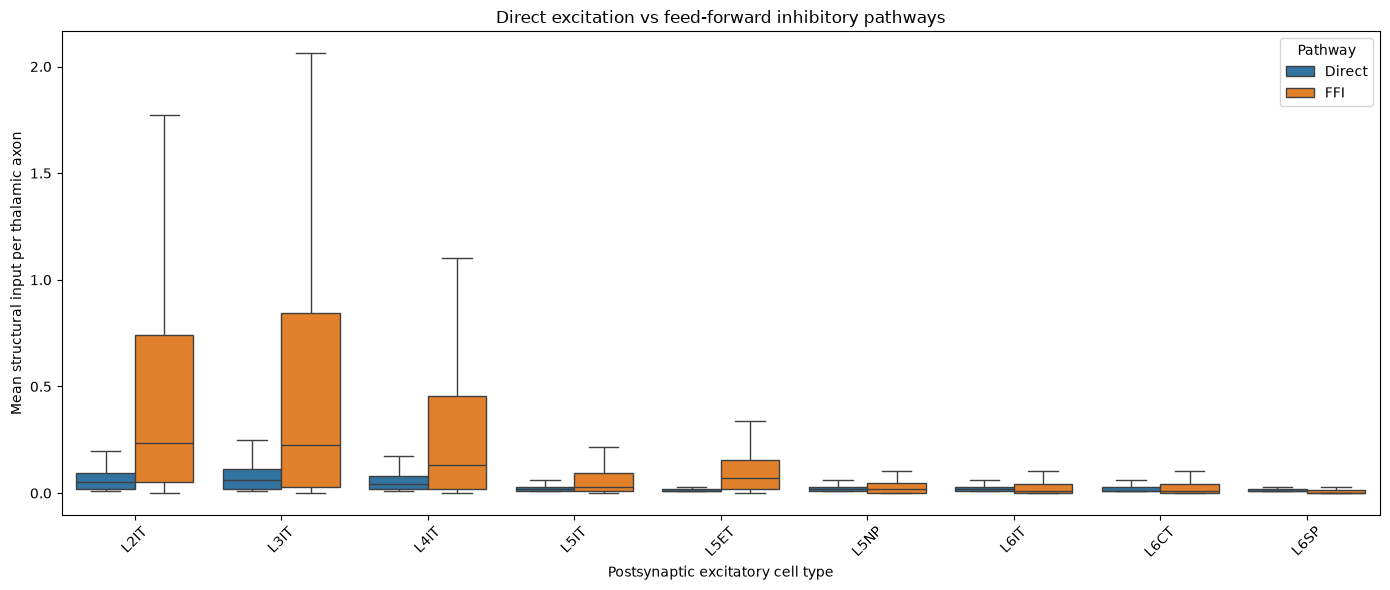

In [ ]:
plot_long = plot_df.melt(
    id_vars=["pt_root_id", "cell_type"],
    value_vars=["Direct", "FFI"],
    var_name="Pathway",
    value_name="Strength"
)

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=plot_long,
    x="cell_type",
    y="Strength",
    hue="Pathway",
    order=celltype_order,
    showfliers=False
)

plt.xlabel("Postsynaptic excitatory cell type")
plt.ylabel("Mean structural input per thalamic axon")
plt.title("Direct excitation vs feed-forward inhibitory pathways")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# direct thalamic input があるとき、どのくらい FFI が accompany するか？

direct_binary = Direct_ct_sorted > 0

# direct connection が存在する T-E pair のみ残す
FFI_conditional = FFI_ct_sorted.where(direct_binary)

# neuronごとに、direct inputを持つthalamic axonsについて平均
ffi_conditional_mean = FFI_conditional.mean(axis=0)

# Directも同じT-E pairsについて
Direct_conditional = Direct_ct_sorted.where(direct_binary)
direct_conditional_mean = Direct_conditional.mean(axis=0)

plot_df_cond = pd.DataFrame({
    "pt_root_id": Direct_ct_sorted.columns,
    "Direct": direct_conditional_mean.values,
    "FFI": ffi_conditional_mean.values,
})

plot_df_cond = plot_df_cond.merge(
    E_meta[["pt_root_id", "cell_type"]],
    on="pt_root_id",
    how="left"
)

plot_long_cond = plot_df_cond.melt(
    id_vars=["pt_root_id", "cell_type"],
    value_vars=["Direct", "FFI"],
    var_name="Pathway",
    value_name="Strength"
)

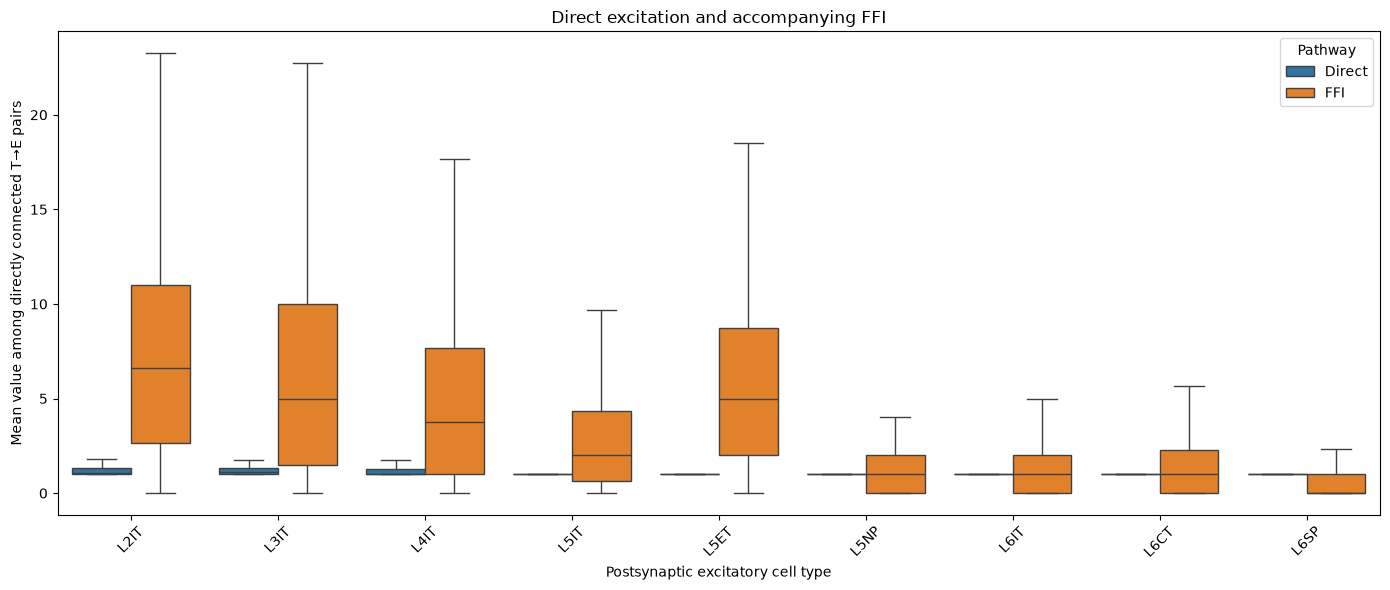

In [ ]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=plot_long_cond,
    x="cell_type",
    y="Strength",
    hue="Pathway",
    order=celltype_order,
    showfliers=False
)

plt.xlabel("Postsynaptic excitatory cell type")
plt.ylabel("Mean value among directly connected T→E pairs")
plt.title("Direct excitation and accompanying FFI")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()